In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from ripser import ripser
from persim import plot_diagrams
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import pairwise_distances
import math
import warnings
warnings.filterwarnings('ignore')

In [2]:
"""Import dataset"""

# Import data
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [3]:
"""Preprocess Data: Remove Duplicates and Missing Values"""

# Check initial counts
initial_count = X.shape[0]

# Remove duplicates
X_clean = X.drop_duplicates()
y_clean = y.loc[X_clean.index]
duplicates_removed = initial_count - X_clean.shape[0]

# Remove missing values
after_duplicates = X_clean.shape[0]
mask = ~X_clean.isnull().any(axis=1)
X_clean = X_clean[mask]
y_clean = y_clean[mask]
missing_removed = after_duplicates - X_clean.shape[0]

# Summary
print(f"Original shape: {initial_count}")
print(f"Duplicates removed: {duplicates_removed}")
print(f"Missing values removed: {missing_removed}")
print(f"Total removed: {duplicates_removed + missing_removed}")
print(f"Cleaned shape: {X_clean.shape[0]}")

# Update X and y
X = X_clean.reset_index(drop=True)
y = y_clean.reset_index(drop=True)

Original shape: 303
Duplicates removed: 0
Missing values removed: 6
Total removed: 6
Cleaned shape: 297


In [4]:
"""Standardize and encode the features"""

# Categorical features
cat_cols = [
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'thal'
]

# Numeric features
num_cols = [c for c in X.columns if c not in cat_cols]

# Encode categoricals
X_cat = pd.get_dummies(X[cat_cols].astype('category'), drop_first=True)

# Scale numerics
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X[num_cols]),
    columns=num_cols,
    index=X.index
)

# Combine
X_scaled = pd.concat([X_num_scaled, X_cat], axis=1)

In [5]:
"""Compute distance matrix"""

distance_matrices = {
    "euclidean": pairwise_distances(X_scaled, metric="euclidean"),
    "cityblock": pairwise_distances(X_scaled, metric="cityblock"),
    "chebyshev": pairwise_distances(X_scaled, metric="chebyshev"),
    "cosine": pairwise_distances(X_scaled, metric="cosine"),
}

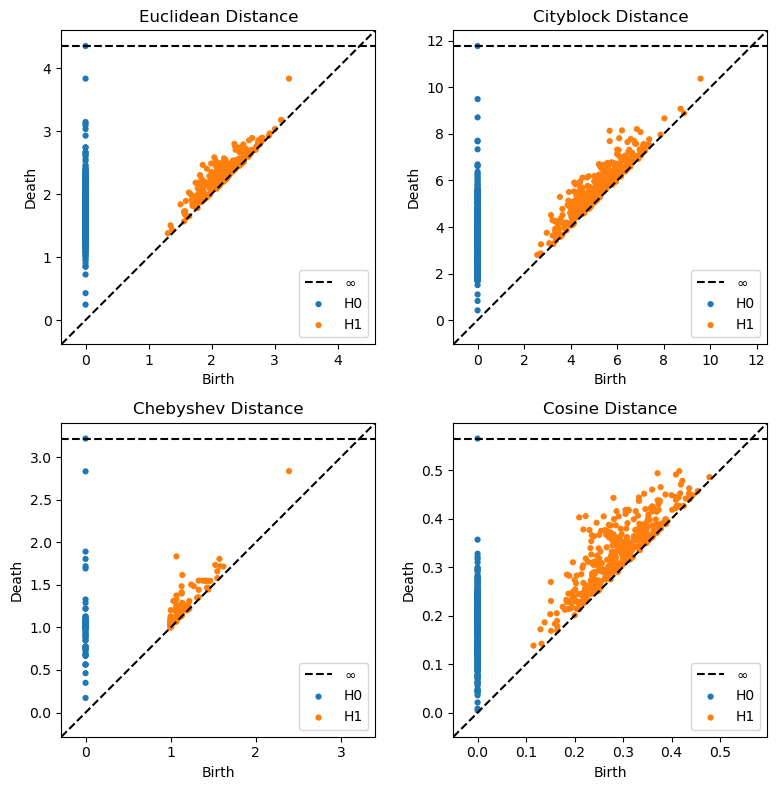

In [12]:
"""Persistence Diagrams plot"""
max_dimension = 1


fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for ax, (metric_name, D) in zip(axes, distance_matrices.items()):
    
    # Compute persistent homology (H0 + H1 only)
    result = ripser(D, maxdim=max_dimension, distance_matrix=True)
    diagrams = result["dgms"]   # diagrams = [H0, H1]
    
    # Plot H0 and H1 directly
    plot_diagrams(diagrams, labels=["H0", "H1"], ax=ax, show=False)
    
    # Title and labels
    ax.set_title(f"{metric_name.capitalize()} Distance")
    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")

plt.tight_layout()
plt.show()


In [6]:
# distance_matrices is assumed to be your dict like:
# distance_matrices = {
#   "euclidean":  pairwise_distances(...),
#   "cityblock":  pairwise_distances(...),
#   "chebyshev":  pairwise_distances(...),
#   "cosine":     pairwise_distances(...),
# }

k = 30
maxdim = 1
progress_every = 25
n_eps = 200

# Store outputs for all metrics here:
# results[metric]["eps_grid"], results[metric]["sr_by_dim"], results[metric]["sr_H0"], results[metric]["sr_H1"]
results = {}

for metric, D in distance_matrices.items():
    # metric-specific eps grid (matches your original logic: 95th percentile per metric)
    max_eps = np.percentile(D, 95)
    eps_grid = np.linspace(0, max_eps, n_eps)

    n = D.shape[0]
    sr_by_dim = {dim: np.zeros((n, len(eps_grid)), dtype=int) for dim in range(maxdim + 1)}

    for i in range(n):
        # local neighborhood + ripser
        drow = D[i]
        nn_idx = np.argsort(drow)[:k]
        D_sub = D[np.ix_(nn_idx, nn_idx)]
        res = ripser(D_sub, distance_matrix=True, maxdim=maxdim)
        dgms = res["dgms"]

        # stable ranks for each homology dimension
        for dim in range(maxdim + 1):
            dgm = dgms[dim]

            if dgm is None or len(dgm) == 0:
                sr_by_dim[dim][i, :] = np.zeros(len(eps_grid), dtype=int)
            else:
                births = dgm[:, 0]
                deaths = dgm[:, 1]

                finite = np.isfinite(deaths)
                if not np.any(finite):
                    sr_by_dim[dim][i, :] = np.zeros(len(eps_grid), dtype=int)
                else:
                    pers = deaths[finite] - births[finite]
                    pers = pers[pers >= 0]

                    sr_by_dim[dim][i, :] = np.array([(pers >= eps).sum() for eps in eps_grid], dtype=int)

        if progress_every and (i + 1) % progress_every == 0:
            print(f"[{metric}] Computed {i+1}/{n} patient stable ranks")

    results[metric] = {
        "eps_grid": eps_grid,
        "sr_by_dim": sr_by_dim,
        "sr_H0": sr_by_dim[0],
        "sr_H1": sr_by_dim[1] if maxdim >= 1 else None,
    }

# Example: access results for a given metric
# sr_H0_euclid = results["euclidean"]["sr_H0"]
# sr_H1_cosine = results["cosine"]["sr_H1"]

# Optional: print shapes for quick verification
for metric in results:
    print(metric, "sr_H0 shape:", results[metric]["sr_H0"].shape,
          "| sr_H1 shape:", None if results[metric]["sr_H1"] is None else results[metric]["sr_H1"].shape)


[euclidean] Computed 25/297 patient stable ranks
[euclidean] Computed 50/297 patient stable ranks
[euclidean] Computed 75/297 patient stable ranks
[euclidean] Computed 100/297 patient stable ranks
[euclidean] Computed 125/297 patient stable ranks
[euclidean] Computed 150/297 patient stable ranks
[euclidean] Computed 175/297 patient stable ranks
[euclidean] Computed 200/297 patient stable ranks
[euclidean] Computed 225/297 patient stable ranks
[euclidean] Computed 250/297 patient stable ranks
[euclidean] Computed 275/297 patient stable ranks
[cityblock] Computed 25/297 patient stable ranks
[cityblock] Computed 50/297 patient stable ranks
[cityblock] Computed 75/297 patient stable ranks
[cityblock] Computed 100/297 patient stable ranks
[cityblock] Computed 125/297 patient stable ranks
[cityblock] Computed 150/297 patient stable ranks
[cityblock] Computed 175/297 patient stable ranks
[cityblock] Computed 200/297 patient stable ranks
[cityblock] Computed 225/297 patient stable ranks
[cityb

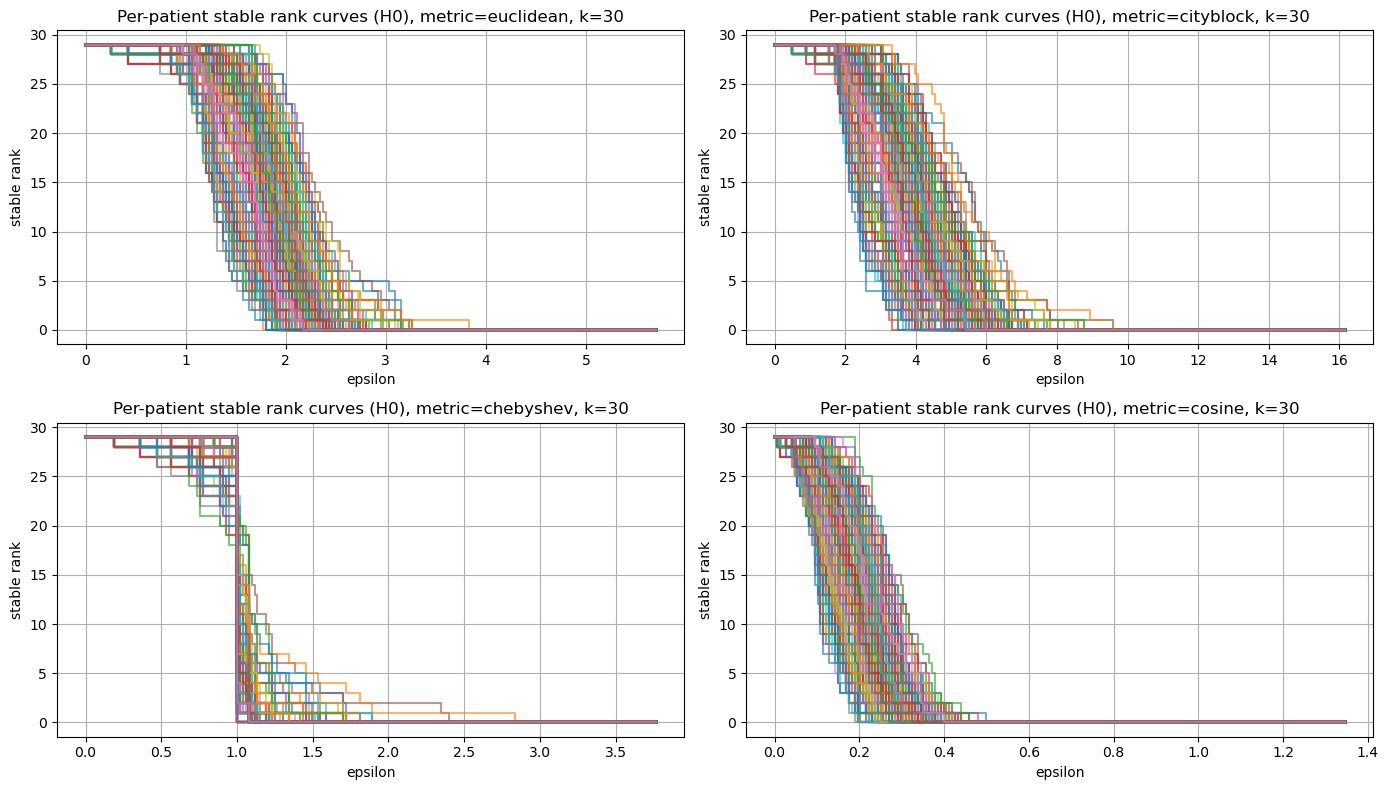

In [7]:
metrics = list(results.keys())  # e.g. ["euclidean","cityblock","chebyshev","cosine"]

# pick the same patient indices across all metrics (based on first metric's n)
n_patients = results[metrics[0]]["sr_H0"].shape[0]
idx_show = np.linspace(0, n_patients - 1, 297, dtype=int)

# grid for subplots (2x2 for 4 metrics, etc.)
n_metrics = len(metrics)
ncols = min(2, n_metrics)
nrows = math.ceil(n_metrics / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows), squeeze=False)

for ax, metric in zip(axes.ravel(), metrics):
    eps_grid = results[metric]["eps_grid"]
    sr_H0 = results[metric]["sr_H0"]

    for i in idx_show:
        ax.step(eps_grid, sr_H0[i], where="post", alpha=0.6)

    ax.set_title(f"Per-patient stable rank curves (H0), metric={metric}, k={k}")
    ax.set_xlabel("epsilon")
    ax.set_ylabel("stable rank")
    ax.grid(True)

# hide any unused axes
for ax in axes.ravel()[len(metrics):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


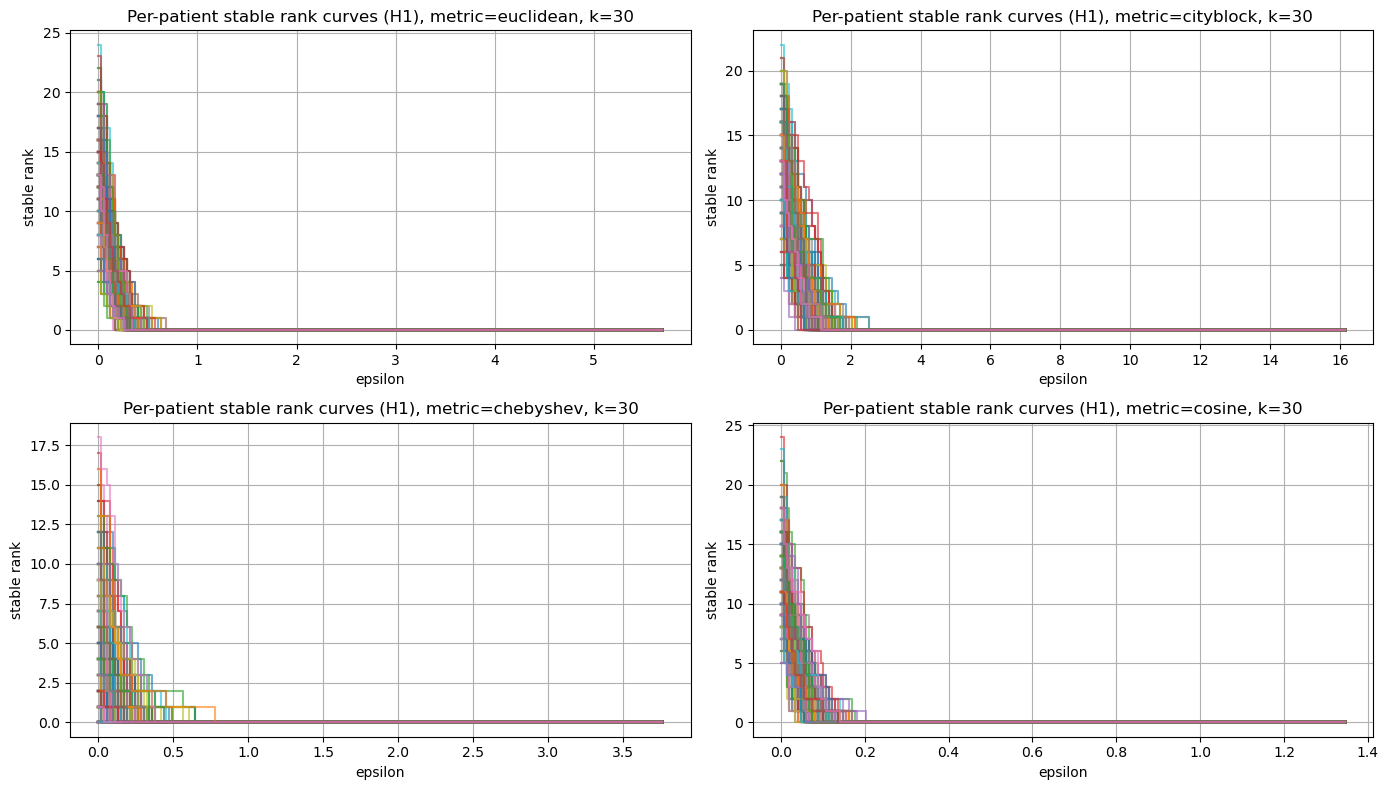

In [8]:
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows), squeeze=False)

for ax, metric in zip(axes.ravel(), metrics):
    eps_grid = results[metric]["eps_grid"]
    sr_H1 = results[metric]["sr_H1"]  # may be None if maxdim < 1

    if sr_H1 is None:
        ax.set_title(f"H1 not computed, metric={metric}")
        ax.axis("off")
        continue

    for i in idx_show:
        ax.step(eps_grid, sr_H1[i], where="post", alpha=0.6)

    ax.set_title(f"Per-patient stable rank curves (H1), metric={metric}, k={k}")
    ax.set_xlabel("epsilon")
    ax.set_ylabel("stable rank")
    ax.grid(True)

for ax in axes.ravel()[len(metrics):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [9]:

# --- turn curves into a compact feature vector per patient ---

# Two simple summaries that work well in practice:
# 1) area-under-curve (AUC) of sr(eps)
# 2) sample sr at fixed epsilon quantiles

from numpy import trapz

sr0_auc = trapz(sr_H0, eps_grid, axis=1)
sr1_auc = trapz(sr_H1, eps_grid, axis=1)

# sample at 10 evenly-spaced eps values (excluding 0)
q_idx = np.linspace(1, len(eps_grid) - 1, 10, dtype=int)

X_sr = pd.DataFrame({
    'sr0_auc': sr0_auc,
    'sr1_auc': sr1_auc,
})

for j, qi in enumerate(q_idx):
    X_sr[f'sr0_e{j}'] = sr_H0[:, qi]
    X_sr[f'sr1_e{j}'] = sr_H1[:, qi]

# Build binary label: any disease vs none (same convention as later in the notebook)
y_bin = (y.iloc[:, 0].astype(int) > 0).astype(int)

print(X_sr.head())
print('Feature matrix shape:', X_sr.shape)


    sr0_auc   sr1_auc  sr0_e0  sr1_e0  sr0_e1  sr1_e1  sr0_e2  sr1_e2  sr0_e3  \
0  7.005637  0.473126      29      13      26       0       4       0       0   
1  4.038464  0.466367      29      13      12       0       0       0       0   
2  3.497749  0.131799      29       6       9       0       0       0       0   
3  6.208083  0.449469      29      11      21       0       4       0       0   
4  3.910044  0.155456      29       6       8       0       1       0       0   

   sr1_e3  ...  sr0_e5  sr1_e5  sr0_e6  sr1_e6  sr0_e7  sr1_e7  sr0_e8  \
0       0  ...       0       0       0       0       0       0       0   
1       0  ...       0       0       0       0       0       0       0   
2       0  ...       0       0       0       0       0       0       0   
3       0  ...       0       0       0       0       0       0       0   
4       0  ...       0       0       0       0       0       0       0   

   sr1_e8  sr0_e9  sr1_e9  
0       0       0       0  
1       0   

In [10]:

# --- baseline model using the per-patient stable-rank features ---

X_train, X_test, y_train, y_test = train_test_split(X_sr, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.6
[[22 10]
 [14 14]]
